<a href="https://colab.research.google.com/github/YannamsettiVenkataLakshmi/credit-card-fraud-detection/blob/main/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
df = pd.read_csv('data/creditcard.csv')

In [44]:
print(df.shape)
df.head()

(122881, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122881 entries, 0 to 122880
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    122881 non-null  int64  
 1   V1      122881 non-null  float64
 2   V2      122881 non-null  float64
 3   V3      122881 non-null  float64
 4   V4      122881 non-null  float64
 5   V5      122881 non-null  float64
 6   V6      122881 non-null  float64
 7   V7      122881 non-null  float64
 8   V8      122881 non-null  float64
 9   V9      122881 non-null  float64
 10  V10     122880 non-null  float64
 11  V11     122880 non-null  float64
 12  V12     122880 non-null  float64
 13  V13     122880 non-null  float64
 14  V14     122880 non-null  float64
 15  V15     122880 non-null  float64
 16  V16     122880 non-null  float64
 17  V17     122880 non-null  float64
 18  V18     122880 non-null  float64
 19  V19     122880 non-null  float64
 20  V20     122880 non-null  float64
 21  V21     12

In [46]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [47]:
df.dropna(inplace=True)

In [48]:
df.shape

(122880, 31)

A single row with missing values across multiple PCA features and the
target variable was identified. Since PCA components do not have
interpretable statistics and the missing count was negligible, the
row was removed.


In [49]:
df.duplicated().sum()

np.int64(473)

In [50]:
df.drop_duplicates(inplace=True)

473 duplicate rows were found and removed to avoid biasing the model
with repeated transactions.


In [51]:
df['Class'] = df['Class'].astype(int)

# EDA

([<matplotlib.patches.Wedge at 0x7fe4f702f620>,
 [Text(-1.0999782539001932, 0.00691671502106343, 'Not Fraud'),
  Text(1.0999782545048673, -0.006916618857906504, 'Fraud')],
 [Text(-0.5999881384910144, 0.0037727536478527795, '99.80'),
  Text(0.5999881388208367, -0.003772701195221729, '0.20')])

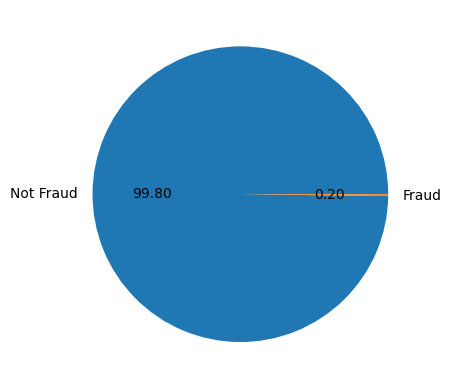

In [52]:
plt.pie(df['Class'].value_counts(),labels=['Not Fraud','Fraud'],autopct='%0.2f')

---> Imbalanced Dataset

In [53]:
df['Amount'].describe()

,Amount
count,122407.000000
mean,94.088023
std,255.434034
min,0.000000
25%,6.790000
50%,24.990000
75%,84.730000
max,19656.530000


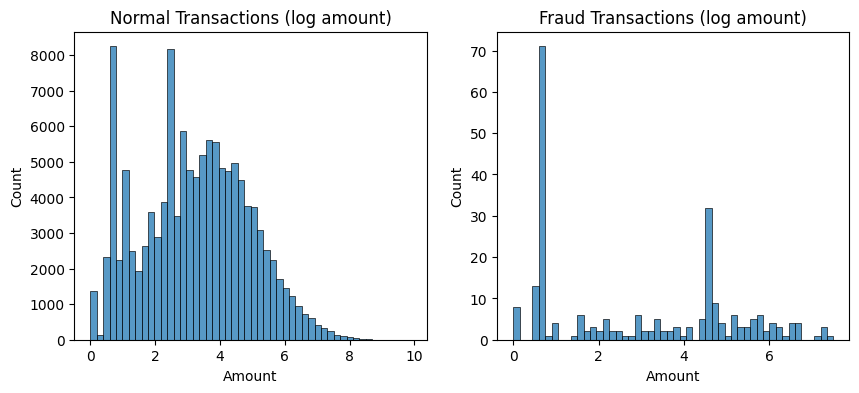

In [54]:
import seaborn as sns
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(np.log1p(df[df['Class']==0]['Amount']),bins=50)
plt.title('Normal Transactions (log amount)')

plt.subplot(1,2,2)
sns.histplot(np.log1p(df[df['Class']==1]['Amount']),bins=50)
plt.title('Fraud Transactions (log amount)')
plt.show()

The transaction amount distribution is highly right-skewed for both
normal and fraudulent transactions. Most transactions occur at very
low amounts.

Fraudulent transactions do not necessarily involve high amounts;
in fact, many frauds occur at small values, likely to avoid detection.
Hence, the Amount feature alone is insufficient to distinguish fraud,
and model performance relies more on the PCA-transformed features.

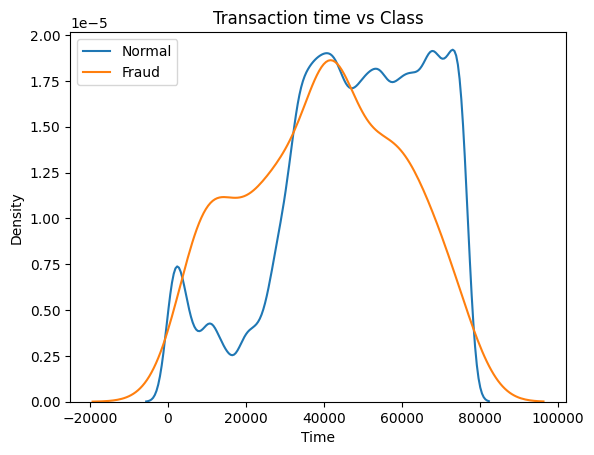

In [55]:
# Time Vs Fraud
sns.kdeplot(df[df['Class']==0]['Time'],label='Normal')
sns.kdeplot(df[df['Class']==1]['Time'],label='Fraud')
plt.title('Transaction time vs Class')
plt.legend()
plt.show()

# Base Line Model

In [59]:
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [60]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [61]:
# scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[['Time','Amount']] = scaler.fit_transform(X_train[['Time','Amount']])
X_test[['Time','Amount']] = scaler.transform(X_test[['Time','Amount']])

In [62]:
X_train

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
62310,0.115902,-6.594052,-7.148079,-1.938030,-1.043239,-1.188479,0.079293,5.291478,-1.498655,1.223583,...,-1.035290,-1.044796,-0.429365,2.562056,-0.244834,0.697417,-0.408063,0.719154,0.565387,5.177441
45128,-0.300519,1.482097,-0.970023,0.429579,-1.312912,-1.517629,-1.001410,-0.846836,-0.285474,-1.930100,...,-0.253000,-0.196503,-0.190573,0.010565,0.385490,0.399420,-0.210393,0.029717,0.025654,-0.235892
80650,0.550730,1.247539,-1.411307,1.273905,-1.257124,-1.397348,1.510582,-1.835549,0.551153,-1.211409,...,-0.430284,-0.092131,0.506190,0.225511,-0.610406,-0.078345,-0.090044,0.157328,0.022810,-0.322824
74657,0.400032,1.244819,-0.601520,0.642892,-0.690740,-1.159492,-0.799115,-0.530797,-0.113212,-1.148524,...,0.226271,0.008744,-0.217084,0.090959,0.531446,0.178426,-0.517755,0.001547,0.025382,-0.122423
53261,-0.109261,-0.568175,-0.365642,1.107008,-2.620935,-0.044712,-0.419629,-0.108308,0.006451,-2.814699,...,-0.397066,-0.391423,-0.922227,0.054283,-0.380352,-0.390851,-0.689941,-0.023255,0.140012,-0.330765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89707,0.764296,-1.573298,0.108900,0.474065,-1.673745,-1.347710,-0.389177,-0.067411,0.491369,-1.247962,...,-1.059350,-0.477142,-0.867303,0.559458,-0.039522,-1.137343,0.429475,-0.511348,-0.282392,0.099439
44559,-0.312167,-0.541029,0.953432,1.657238,-0.144602,0.163300,-0.232494,0.539529,0.176926,-0.756837,...,0.116975,-0.125351,-0.285420,0.020901,0.220575,-0.302957,0.068907,0.280594,0.111518,-0.355016
8494,-1.903954,-0.690427,0.350878,1.699592,-0.832879,0.170930,-0.258965,0.400081,0.041517,1.301714,...,-0.039086,-0.109553,-0.039621,-0.169671,0.016577,-0.057483,0.898679,-0.030767,0.085358,-0.226362
9690,-1.743689,1.165468,-0.162478,0.848212,0.168544,-0.678224,-0.070798,-0.690036,0.140948,1.628902,...,-0.173660,-0.000827,0.213883,0.016145,0.006617,0.070471,1.047418,-0.082855,-0.010532,-0.315269


In [64]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
lor = LogisticRegression(max_iter=100,class_weight='balanced')

In [65]:
lor.fit(X_train,y_train)

LogisticRegression(class_weight='balanced')

In [67]:
y_pred = lor.predict(X_test)
print('Accuracy score : ',accuracy_score(y_test,y_pred))
print('Confusion matrix : \n',confusion_matrix(y_test,y_pred))
print('Classification Report : \n',classification_report(y_test,y_pred))

Accuracy score :  0.9819867657871089
Confusion matrix : 
 [[24001   432]
 [    9    40]]
Classification Report : 
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     24433
           1       0.08      0.82      0.15        49

    accuracy                           0.98     24482
   macro avg       0.54      0.90      0.57     24482
weighted avg       1.00      0.98      0.99     24482



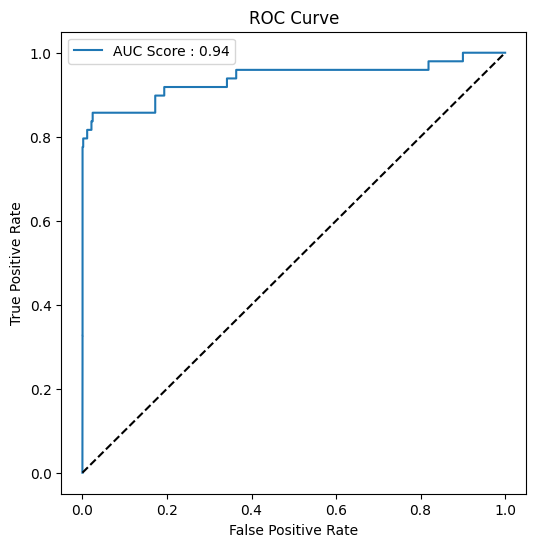

In [70]:
from sklearn.metrics import roc_auc_score,roc_curve,precision_recall_curve,average_precision_score
y_prob = lor.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(y_test,y_prob)
fpr,tpr,thresholds = roc_curve(y_test,y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,label=f'AUC Score : {auc_score:.2f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


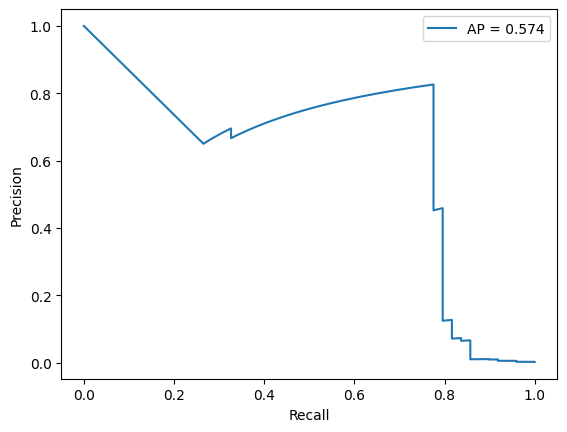

In [72]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [73]:
target_recall = 0.80

valid_idx = np.where(recall[:-1] >= target_recall)[0]
best_idx = valid_idx[np.argmax(precision[valid_idx])]

best_threshold = thresholds[best_idx]
best_threshold

np.float64(0.675969607804141)

-->
Although ROC-AUC indicated strong ranking performance, threshold
selection was performed using the precision–recall curve due to severe
class imbalance. The optimal threshold was derived by enforcing a
minimum recall for the positive class and maximizing precision under
this constraint.


In [74]:
y_pred_final = (y_prob >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

[[24158   275]
 [    9    40]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     24433
           1       0.13      0.82      0.22        49

    accuracy                           0.99     24482
   macro avg       0.56      0.90      0.61     24482
weighted avg       1.00      0.99      0.99     24482



--> At the selected threshold, the model detects ~82% of fraudulent
transactions while flagging a small fraction of legitimate transactions.
This trade-off is acceptable in fraud detection where false negatives
are more costly than false positives.


# XgBoost

In [75]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
scale_pos_weight

np.float64(498.6173469387755)

In [76]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [82]:
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [88]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

target_recall = 0.85
valid_idx = np.where(recall[:-1] >= target_recall)[0]

best_idx = valid_idx[np.argmax(precision[valid_idx])]
best_threshold_xgb = thresholds[best_idx]

best_threshold_xgb

np.float32(0.00039664685)

In [89]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_xgb = (y_prob_xgb >= best_threshold_xgb).astype(int)

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

[[22837  1596]
 [    7    42]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.97     24433
           1       0.03      0.86      0.05        49

    accuracy                           0.93     24482
   macro avg       0.51      0.90      0.51     24482
weighted avg       1.00      0.93      0.96     24482



--> Although XGBoost achieved higher recall at aggressive thresholds, it
resulted in a substantial increase in false positives. No operating
point satisfied both recall ≥ 0.82 and precision ≥ 0.10 simultaneously.
Therefore, Logistic Regression was selected as the final model due to
its superior precision–recall trade-off and operational feasibility.
